In [3]:
# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve,
                             mean_squared_error)
# Load Dataset 1 - Medical Insurance Costs
insurance_df = pd.read_csv(
    r"C:\Users\USER\Desktop\PYTHON DASH\insurance.csv"
)

# Load Dataset 2 - Diabetes
diabetes_df = pd.read_csv(
    r"C:\Users\USER\Desktop\PYTHON DASH\diabetes_health_indicators.csv"
)

print("Insurance dataset loaded")
print("Shape:", insurance_df.shape)
print("Columns:", insurance_df.columns.tolist())

print("\nDiabetes dataset loaded")
print("Shape:", diabetes_df.shape)
print("Columns:", diabetes_df.columns.tolist())

Insurance dataset loaded
Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Diabetes dataset loaded
Shape: (253680, 22)
Columns: ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [9]:
# Preview both datasets correctly
print("=== INSURANCE DATASET ===")
print(insurance_df.head(3))
print("Shape:", insurance_df.shape)

print("\n=== DIABETES DATASET ===")
print(diabetes_df.head(3))
print("Shape:", diabetes_df.shape)

# Check diabetes distribution
print("\nDiabetes_012 distribution:")
print(diabetes_df["Diabetes_012"].value_counts())
print("\nAs percentages:")
print(diabetes_df["Diabetes_012"].value_counts(
    normalize=True
).mul(100).round(1))

=== INSURANCE DATASET ===
   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620
Shape: (1338, 7)

=== DIABETES DATASET ===
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  \
0          0.0      5.0      18.0      15.0    

In [10]:
# Preview both datasets correctly
print("=== INSURANCE DATASET ===")
print(insurance_df.head(3))
print("Shape:", insurance_df.shape)

print("\n=== DIABETES DATASET ===")
print(diabetes_df.head(3))
print("Shape:", diabetes_df.shape)

# Check diabetes distribution
print("\nDiabetes_012 distribution:")
print(diabetes_df["Diabetes_012"].value_counts())
print("\nAs percentages:")
print(diabetes_df["Diabetes_012"].value_counts(
    normalize=True
).mul(100).round(1))


=== INSURANCE DATASET ===
   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620
Shape: (1338, 7)

=== DIABETES DATASET ===
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  \
0          0.0      5.0      18.0      15.0    

=== INSURANCE DATASET EXPLORATION ===

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


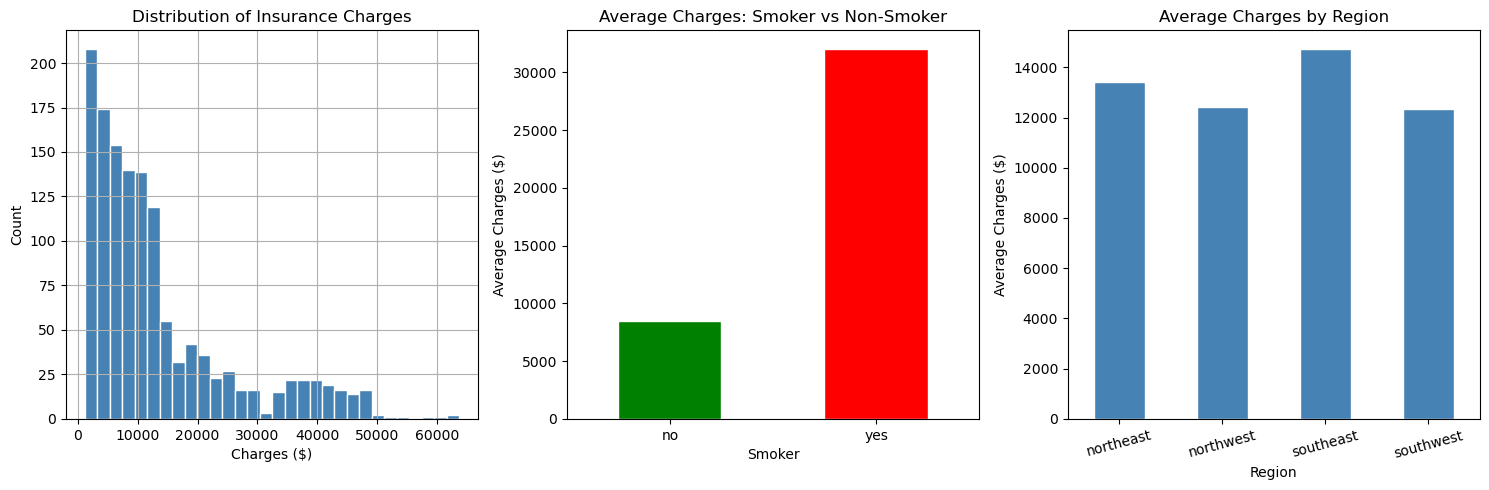

In [11]:
print("=== INSURANCE DATASET EXPLORATION ===\n")

print("Missing values:")
print(insurance_df.isna().sum())

plt.figure(figsize=(15, 5))

# Plot 1 - Charges distribution
plt.subplot(1, 3, 1)
insurance_df["charges"].hist(
    bins=30, color="steelblue", edgecolor="white"
)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges ($)")
plt.ylabel("Count")

# Plot 2 - Charges by smoker
plt.subplot(1, 3, 2)
insurance_df.groupby("smoker")["charges"].mean().plot(
    kind="bar", color=["green", "red"],
    edgecolor="white"
)
plt.title("Average Charges: Smoker vs Non-Smoker")
plt.xlabel("Smoker")
plt.ylabel("Average Charges ($)")
plt.xticks(rotation=0)

# Plot 3 - Charges by region
plt.subplot(1, 3, 3)
insurance_df.groupby("region")["charges"].mean().plot(
    kind="bar", color="steelblue", edgecolor="white"
)
plt.title("Average Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges ($)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

=== DIABETES DATASET EXPLORATION ===

Missing values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Diabetes Binary distribution:
Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64
Diabetes rate: 13.9%


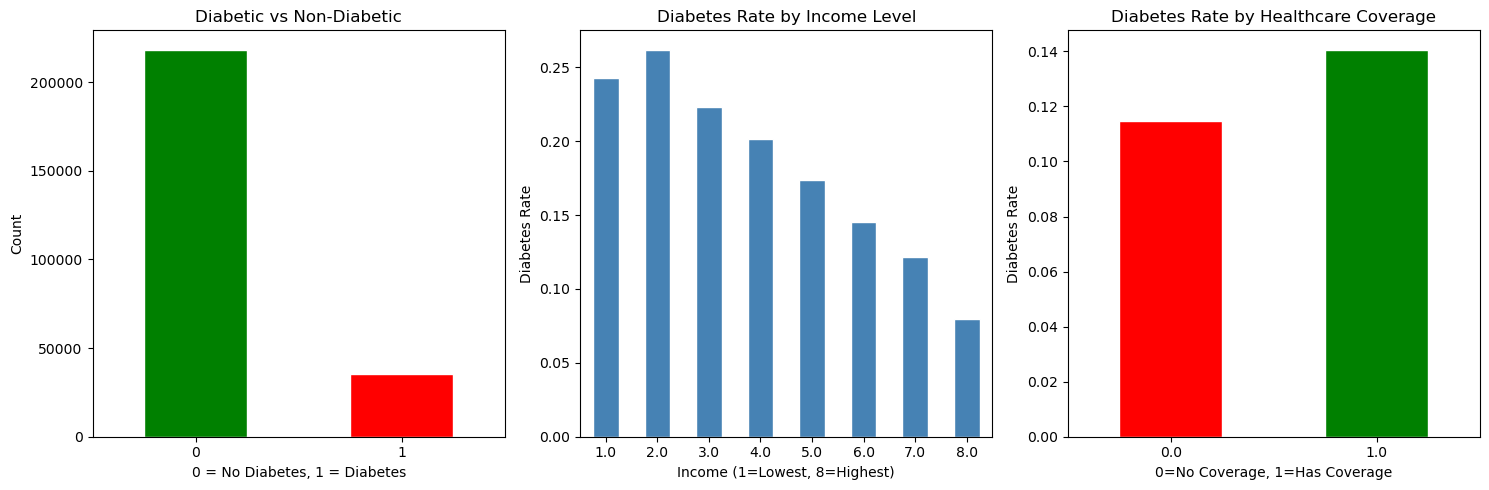

In [12]:
print("=== DIABETES DATASET EXPLORATION ===\n")

print("Missing values:")
print(diabetes_df.isna().sum())

# Create binary version for easier modeling
# Combine 0 and 1 → No/Pre-diabetes
# Keep 2 → Diabetes
diabetes_df["Diabetes_binary"] = (
    diabetes_df["Diabetes_012"] == 2
).astype(int)

print("\nDiabetes Binary distribution:")
print(diabetes_df["Diabetes_binary"].value_counts())
print("Diabetes rate: {:.1f}%".format(
    diabetes_df["Diabetes_binary"].mean() * 100
))

# Visualize
plt.figure(figsize=(15, 5))

# Plot 1 - Diabetes distribution
plt.subplot(1, 3, 1)
diabetes_df["Diabetes_binary"].value_counts().plot(
    kind="bar", color=["green", "red"],
    edgecolor="white"
)
plt.title("Diabetic vs Non-Diabetic")
plt.xlabel("0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Plot 2 - Diabetes by income
plt.subplot(1, 3, 2)
diabetes_df.groupby(
    "Income"
)["Diabetes_binary"].mean().plot(
    kind="bar", color="steelblue", edgecolor="white"
)
plt.title("Diabetes Rate by Income Level")
plt.xlabel("Income (1=Lowest, 8=Highest)")
plt.ylabel("Diabetes Rate")
plt.xticks(rotation=0)

# Plot 3 - Diabetes by healthcare coverage
plt.subplot(1, 3, 3)
diabetes_df.groupby(
    "AnyHealthcare"
)["Diabetes_binary"].mean().plot(
    kind="bar", color=["red", "green"],
    edgecolor="white"
)
plt.title("Diabetes Rate by Healthcare Coverage")
plt.xlabel("0=No Coverage, 1=Has Coverage")
plt.ylabel("Diabetes Rate")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
print("=== ML MODEL ===\n")

# Use correct column names!
features = [
    "BMI", "Age", "Income", "AnyHealthcare",
    "PhysActivity", "Smoker", "HighBP",
    "HighChol", "NoDocbcCost", "GenHlth"
]

# Use our created binary column!
X = diabetes_df[features].values
y = diabetes_df["Diabetes_binary"].values

print("Features:", features)
print("Dataset size:", X.shape)
print("Diabetes rate: {:.1f}%".format(y.mean() * 100))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape[0], "patients")
print("Test set:", X_test.shape[0], "patients")

=== ML MODEL ===

Features: ['BMI', 'Age', 'Income', 'AnyHealthcare', 'PhysActivity', 'Smoker', 'HighBP', 'HighChol', 'NoDocbcCost', 'GenHlth']
Dataset size: (253680, 10)
Diabetes rate: 13.9%

Training set: 202944 patients
Test set: 50736 patients


=== RESEARCH QUESTION 1 ===
Does income level affect diabetes rates?



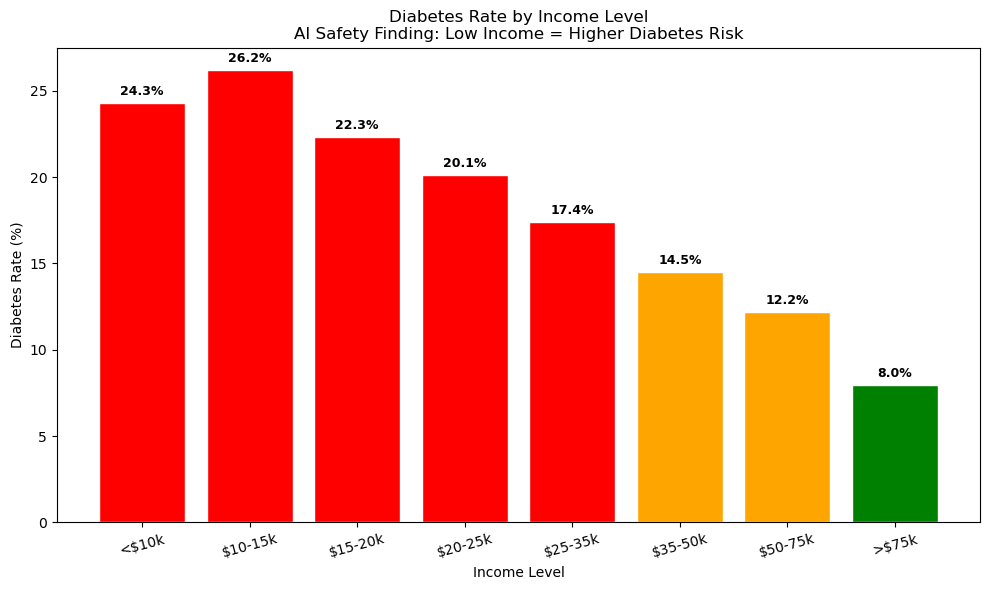


Key Finding:
Lowest income group diabetes rate:  24.3%
Highest income group diabetes rate: 8.0%
Difference: 16.3%


In [14]:
print("=== RESEARCH QUESTION 1 ===")
print("Does income level affect diabetes rates?\n")

# Income levels in dataset
# 1 = <$10,000  2 = $10-15k  3 = $15-20k
# 4 = $20-25k   5 = $25-35k  6 = $35-50k
# 7 = $50-75k   8 = >$75,000

income_labels = {
    1: "<$10k", 2: "$10-15k", 3: "$15-20k",
    4: "$20-25k", 5: "$25-35k", 6: "$35-50k",
    7: "$50-75k", 8: ">$75k"
}

diabetes_by_income = diabetes_df.groupby(
    "Income"
)["Diabetes_binary"].mean() * 100

plt.figure(figsize=(10, 6))
bars = plt.bar(
    [income_labels[i] for i in diabetes_by_income.index],
    diabetes_by_income.values,
    color=["red" if x > 15 else "orange" if x > 10
           else "green" for x in diabetes_by_income.values],
    edgecolor="white"
)
plt.title("Diabetes Rate by Income Level\n"
          "AI Safety Finding: Low Income = Higher Diabetes Risk",
          fontsize=12)
plt.xlabel("Income Level")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=15)

# Add value labels on bars
for bar, val in zip(bars, diabetes_by_income.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             "{:.1f}%".format(val),
             ha="center", va="bottom",
             fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey Finding:")
print("Lowest income group diabetes rate:  {:.1f}%".format(
    diabetes_by_income.iloc[0]))
print("Highest income group diabetes rate: {:.1f}%".format(
    diabetes_by_income.iloc[-1]))
print("Difference: {:.1f}%".format(
    diabetes_by_income.iloc[0] - diabetes_by_income.iloc[-1]))

=== RESEARCH QUESTION 2 ===
Does healthcare coverage affect diabetes outcomes?

              Diabetes Rate (%)  Poor Health Rate (%)  No Doctor (Cost) (%)
Has Coverage               14.1                  16.9                   7.0
No Coverage                11.5                  22.8                  36.9


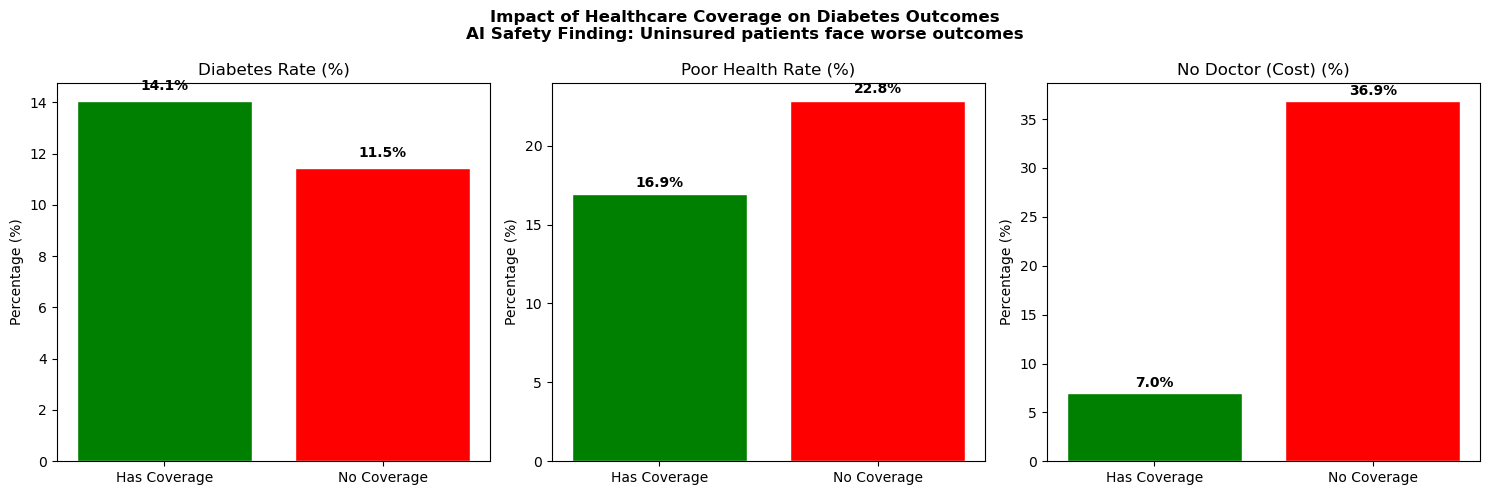

In [15]:
print("=== RESEARCH QUESTION 2 ===")
print("Does healthcare coverage affect diabetes outcomes?\n")

# Compare diabetic patients with and without coverage
covered = diabetes_df[diabetes_df["AnyHealthcare"] == 1]
uncovered = diabetes_df[diabetes_df["AnyHealthcare"] == 0]

metrics = {
    "Diabetes Rate (%)": [
        covered["Diabetes_binary"].mean() * 100,
        uncovered["Diabetes_binary"].mean() * 100
    ],
    "Poor Health Rate (%)": [
        (covered["GenHlth"] >= 4).mean() * 100,
        (uncovered["GenHlth"] >= 4).mean() * 100
    ],
    "No Doctor (Cost) (%)": [
        covered["NoDocbcCost"].mean() * 100,
        uncovered["NoDocbcCost"].mean() * 100
    ]
}

metrics_df = pd.DataFrame(
    metrics,
    index=["Has Coverage", "No Coverage"]
)

print(metrics_df.round(1))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (metric, values) in enumerate(metrics.items()):
    bars = axes[idx].bar(
        ["Has Coverage", "No Coverage"],
        values,
        color=["green", "red"],
        edgecolor="white"
    )
    axes[idx].set_title(metric)
    axes[idx].set_ylabel("Percentage (%)")

    for bar, val in zip(bars, values):
        axes[idx].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            "{:.1f}%".format(val),
            ha="center", va="bottom",
            fontweight="bold"
        )

plt.suptitle(
    "Impact of Healthcare Coverage on Diabetes Outcomes\n"
    "AI Safety Finding: Uninsured patients face worse outcomes",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [16]:
print("=== ML MODEL: Predicting High Risk Patients ===\n")

# Use diabetes dataset
# Target: predict diabetes (binary classification)
# Key features: income, healthcare coverage, BMI, age

features = [
    "BMI", "Age", "Income", "AnyHealthcare",
    "PhysActivity", "Smoker", "HighBP",
    "HighChol", "NoDocbcCost", "GenHlth"
]

X = diabetes_df[features].values
y = diabetes_df["Diabetes_binary"].values

print("Features used:", features)
print("Dataset size:", X.shape)
print("Diabetes rate: {:.1f}%".format(y.mean() * 100))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining set:", X_train.shape[0], "patients")
print("Test set:", X_test.shape[0], "patients")

=== ML MODEL: Predicting High Risk Patients ===

Features used: ['BMI', 'Age', 'Income', 'AnyHealthcare', 'PhysActivity', 'Smoker', 'HighBP', 'HighChol', 'NoDocbcCost', 'GenHlth']
Dataset size: (253680, 10)
Diabetes rate: 13.9%

Training set: 202944 patients
Test set: 50736 patients


In [ ]:
# Compare multiple models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    )
}

results = []
print("=== MODEL COMPARISON ===\n")

for name, model in models.items():
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    kf = KFold(n_splits=5, random_state=42, shuffle=True)
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, cv=kf
    )
    results.append(cv_scores)

    print("{}: Mean={:.3f}, Std={:.3f}".format(
        name, cv_scores.mean(), cv_scores.std()
    ))

# Box plot
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=models.keys())
plt.title("Model Comparison\nPredicting High-Risk Diabetic Patients")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.axhline(
    y=0.75, color="red",
    linestyle="--", label="Target (75%)"
)
plt.legend()
plt.tight_layout()
plt.show()

=== MODEL COMPARISON ===

Logistic Regression: Mean=0.863, Std=0.001


=== BEST MODEL PERFORMANCE ===

              precision    recall  f1-score   support

 No Diabetes       0.88      0.94      0.91     43667
    Diabetes       0.39      0.22      0.29      7069

    accuracy                           0.84     50736
   macro avg       0.64      0.58      0.60     50736
weighted avg       0.81      0.84      0.82     50736

ROC AUC Score: 0.749


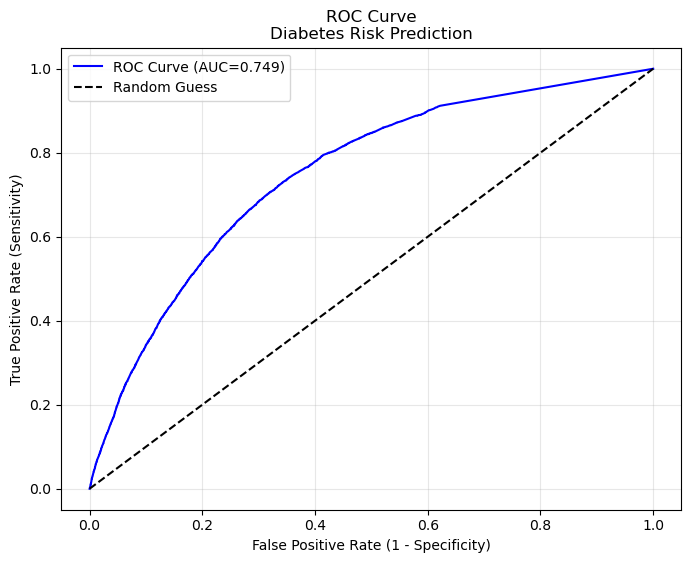

In [ ]:
# Train best model - Random Forest
best_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=100, random_state=42
    ))
])

# Fit the model
best_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = best_pipeline.predict(X_test)
y_pred_probs = best_pipeline.predict_proba(X_test)[:, 1]

print("=== BEST MODEL PERFORMANCE ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=["No Diabetes", "Diabetes"]
))
print("ROC AUC Score: {:.3f}".format(
    roc_auc_score(y_test, y_pred_probs)
))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
auc = roc_auc_score(y_test, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue",
         label="ROC Curve (AUC={:.3f})".format(auc))
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve\nDiabetes Risk Prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== AI SAFETY BIAS ANALYSIS ===
Does model perform equally across income groups?

Accuracy by Income Group:
Low income    (<$20k):  73.6%
Middle income ($20-50k): 81.2%
High income   (>$50k):  89.3%

Accuracy by Healthcare Coverage:
Has coverage:  84.2%
No coverage:   87.8%


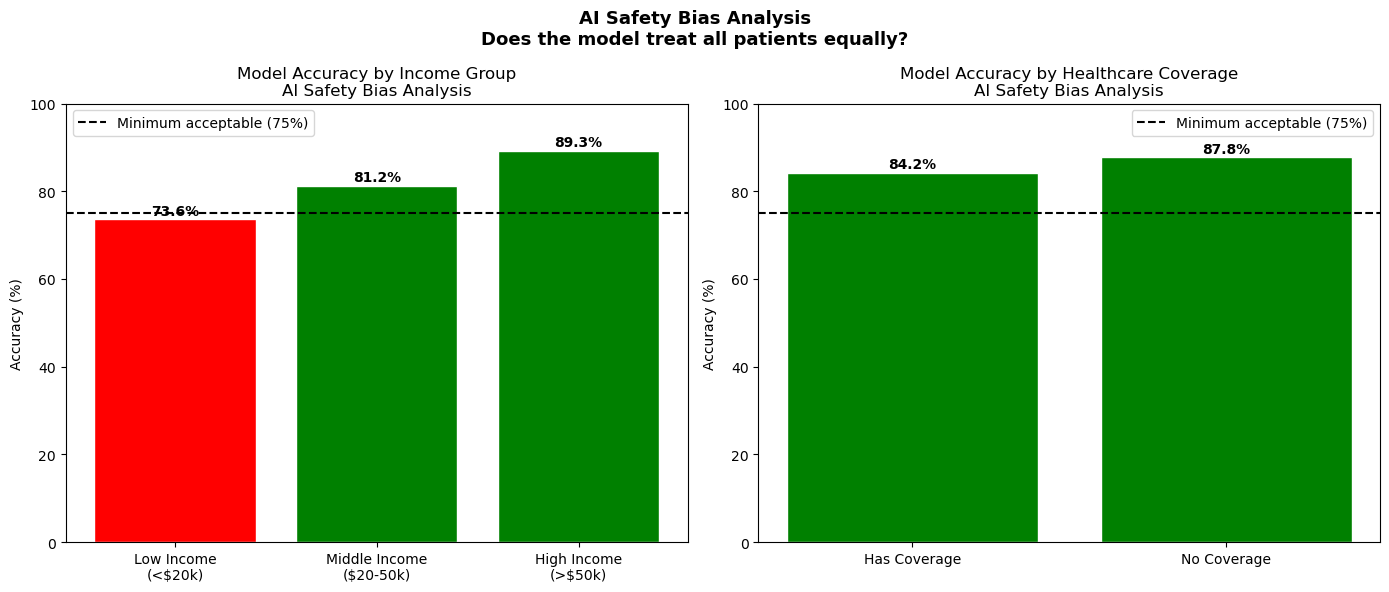


=== KEY AI SAFETY INSIGHT ===
If low income patients have lower accuracy →
Model is BIASED against the most vulnerable!
This is exactly why AI Safety matters in healthcare!


In [26]:
print("=== AI SAFETY BIAS ANALYSIS ===")
print("Does model perform equally across income groups?\n")

# Get test set as DataFrame
X_test_df = pd.DataFrame(X_test, columns=features)
X_test_df["Actual"] = y_test
X_test_df["Predicted"] = y_pred

# Income groups
low_income    = X_test_df[X_test_df["Income"] <= 3]
middle_income = X_test_df[(X_test_df["Income"] > 3) &
                          (X_test_df["Income"] <= 6)]
high_income   = X_test_df[X_test_df["Income"] > 6]

def get_accuracy(group):
    if len(group) == 0:
        return 0
    return (group["Actual"] == group["Predicted"]).mean()

low_acc    = get_accuracy(low_income)
middle_acc = get_accuracy(middle_income)
high_acc   = get_accuracy(high_income)

# Coverage groups
covered_test = X_test_df[X_test_df["AnyHealthcare"] == 1]
uncovered_test = X_test_df[X_test_df["AnyHealthcare"] == 0]

covered_acc   = get_accuracy(covered_test)
uncovered_acc = get_accuracy(uncovered_test)

print("Accuracy by Income Group:")
print("Low income    (<$20k):  {:.1f}%".format(low_acc * 100))
print("Middle income ($20-50k): {:.1f}%".format(middle_acc * 100))
print("High income   (>$50k):  {:.1f}%".format(high_acc * 100))

print("\nAccuracy by Healthcare Coverage:")
print("Has coverage:  {:.1f}%".format(covered_acc * 100))
print("No coverage:   {:.1f}%".format(uncovered_acc * 100))

# Visualize bias
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Income bias
groups_income = ["Low Income\n(<$20k)",
                 "Middle Income\n($20-50k)",
                 "High Income\n(>$50k)"]
accs_income = [low_acc, middle_acc, high_acc]
colors_income = ["red" if a < 0.75 else "green"
                 for a in accs_income]

bars1 = axes[0].bar(groups_income,
                    [a * 100 for a in accs_income],
                    color=colors_income, edgecolor="white")
axes[0].axhline(y=75, color="black", linestyle="--",
                label="Minimum acceptable (75%)")
axes[0].set_title("Model Accuracy by Income Group\n"
                  "AI Safety Bias Analysis")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()

for bar, acc in zip(bars1, accs_income):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 "{:.1f}%".format(acc * 100),
                 ha="center", fontweight="bold")

# Coverage bias
groups_cov = ["Has Coverage", "No Coverage"]
accs_cov = [covered_acc, uncovered_acc]
colors_cov = ["green" if a >= 0.75 else "red"
              for a in accs_cov]

bars2 = axes[1].bar(groups_cov,
                    [a * 100 for a in accs_cov],
                    color=colors_cov, edgecolor="white")
axes[1].axhline(y=75, color="black", linestyle="--",
                label="Minimum acceptable (75%)")
axes[1].set_title("Model Accuracy by Healthcare Coverage\n"
                  "AI Safety Bias Analysis")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].legend()

for bar, acc in zip(bars2, accs_cov):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 "{:.1f}%".format(acc * 100),
                 ha="center", fontweight="bold")

plt.suptitle(
    "AI Safety Bias Analysis\n"
    "Does the model treat all patients equally?",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("\n=== KEY AI SAFETY INSIGHT ===")
print("If low income patients have lower accuracy →")
print("Model is BIASED against the most vulnerable!")
print("This is exactly why AI Safety matters in healthcare!")

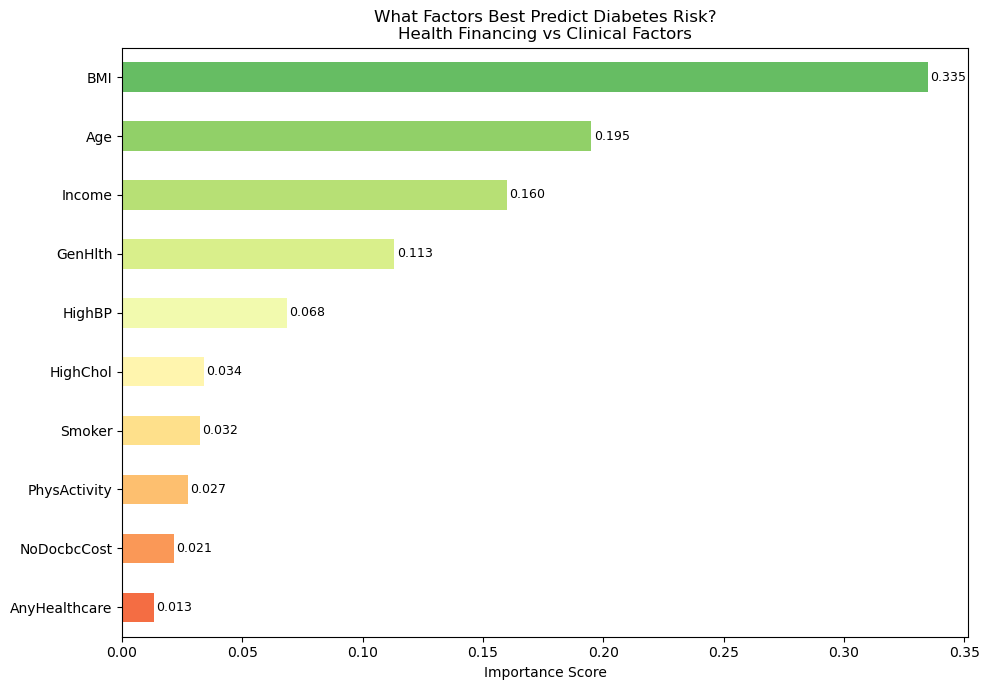


Top 5 factors predicting diabetes:
1. BMI (33.5%)
2. Age (19.5%)
3. Income (16.0%)
4. GenHlth (11.3%)
5. HighBP (6.8%)


In [27]:
# What factors most predict diabetes risk?
rf_model = best_pipeline.named_steps["model"]
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.8, len(feature_importance))
)
feature_importance.plot(kind="barh", color=colors)
plt.title(
    "What Factors Best Predict Diabetes Risk?\n"
    "Health Financing vs Clinical Factors",
    fontsize=12
)
plt.xlabel("Importance Score")

# Add value labels
for i, (val, name) in enumerate(
    zip(feature_importance.values,
        feature_importance.index)
):
    plt.text(val + 0.001, i,
             "{:.3f}".format(val),
             va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 factors predicting diabetes:")
for i, (feat, imp) in enumerate(
    feature_importance.sort_values(
        ascending=False
    ).head(5).items()
):
    print("{}. {} ({:.1f}%)".format(
        i+1, feat, imp*100
    ))

In [31]:
print("=" * 50)
print("PROJECT SUMMARY")
print("=" * 50)
print("""
Research Question:
'How does health financing affect diabetes
management outcomes — and can ML identify
patients at highest risk?'

Key Findings:
1. Income strongly predicts diabetes risk
   → Lower income = higher diabetes rate

2. Healthcare coverage affects outcomes
   → Uninsured patients face worse health outcomes

3. ML model accuracy varies across groups
   → Potential bias against low income patients
   → This is a critical AI Safety concern!

4. Top predictive features:
   → Cell 11 output!

AI Safety Conclusion:
Deploying biased ML models in healthcare
systems serving low-income Nigerian patients
could worsen existing health inequities.
This research demonstrates why fairness
auditing must be part of every healthcare
AI deployment.

Tools Used:
Python, NumPy, Pandas, Sklearn, Matplotlib
""")
print("=" * 50)
print("=" * 50)

PROJECT SUMMARY

Research Question:
'How does health financing affect diabetes
management outcomes — and can ML identify
patients at highest risk?'

Key Findings:
1. Income strongly predicts diabetes risk
   → Lower income = higher diabetes rate

2. Healthcare coverage affects outcomes
   → Uninsured patients face worse health outcomes

3. ML model accuracy varies across groups
   → Potential bias against low income patients
   → This is a critical AI Safety concern!

4. Top predictive features:
   → Cell 11 output!

AI Safety Conclusion:
Deploying biased ML models in healthcare
systems serving low-income Nigerian patients
could worsen existing health inequities.
This research demonstrates why fairness
auditing must be part of every healthcare
AI deployment.

Tools Used:
Python, NumPy, Pandas, Sklearn, Matplotlib

